In [1]:
from import_dados import *
from polars import col as c
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df_pessoas = read_pessoas().pipe(trata_pessoas)
df_sinistros = read_sinistros()

In [3]:
df_pessoas.null_count()

id_sinistro,id_pessoa,id_veiculo,cod_ibge,municipio,regiao_administrativa,tipo_via,tipo_veiculo_vitima,tipo_de_vitima,modo_transporte_vitima,sexo,idade,gravidade_lesao,faixa_etaria_demografica,faixa_etaria_legal,profissao,grau_de_instrucao,nacionalidade,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,ano_mes_sinistro,data_obito,ano_obito,mes_obito,dia_obito,ano_mes_obito,local_obito,local_via,tempo_sinistro_obito
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,2766,0,0,0,0,2741,0,0,0,901,0,0,0,3739,36859,4021,0,0,0,0,0,42766,42766,42766,42766,42766,42766,2546,42766


In [4]:
df_pessoas.filter(c('modo_transporte_vitima').is_null()).group_by('tempo_sinistro_obito').len()

tempo_sinistro_obito,len
i64,u32


In [5]:
df_pessoas.group_by().agg(pl.col('id_sinistro').n_unique())

id_sinistro
u32
23426


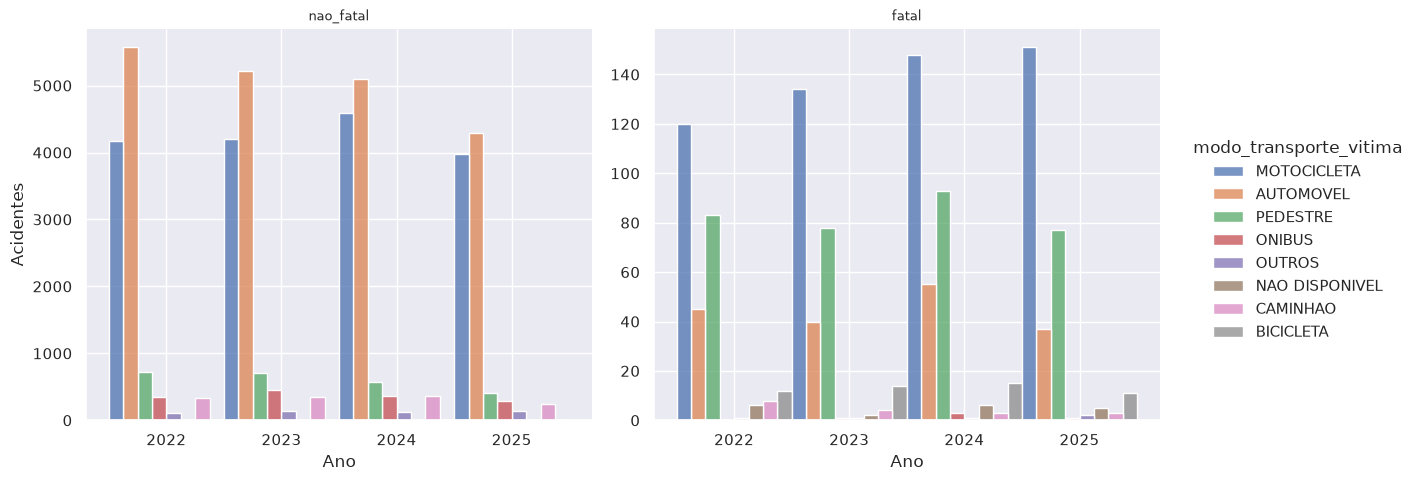

In [ ]:
df_plot = df_pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('fatalidade')) \
        .join(df_sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
                .select('modo_transporte_vitima', 
                 'tp_sinistro_primario',
                 'fatalidade',
                 'ano_sinistro').to_pandas()

g = sns.displot(data=df_plot, 
            x='ano_sinistro',
            hue='modo_transporte_vitima',
            multiple='dodge', 
            col='fatalidade',
           height=5, aspect=1.2, 
           facet_kws={'sharey': False},  
           ) \
        .set_ylabels(label='Acidentes') \
        .set_xlabels(label='Ano') \
        .set_titles(col_template="{col_name}", row_template="{row_name}", size=9) \

plt.show()

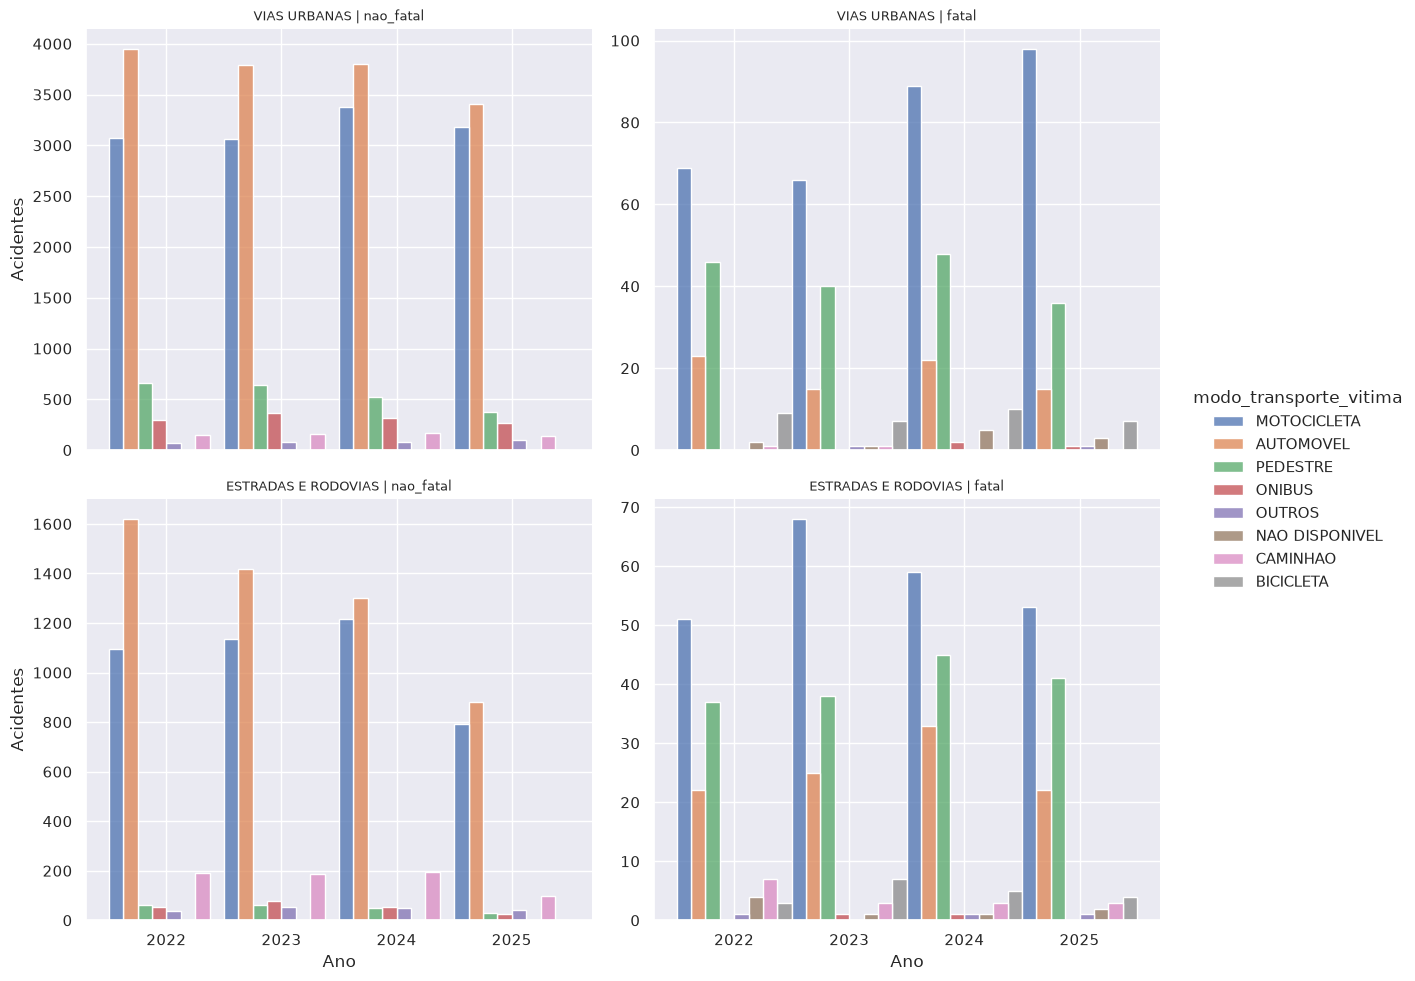

In [25]:
df_plot = df_pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('fatalidade')) \
        .join(df_sinistros.select('id_sinistro', 'tp_sinistro_primario', 'tipo_via'), on='id_sinistro') \
                .select('modo_transporte_vitima', 
                 'tp_sinistro_primario',
                 'fatalidade',
                 'ano_sinistro',
                 'tipo_via').to_pandas()

g = sns.displot(data=df_plot, 
            x='ano_sinistro',
            hue='modo_transporte_vitima',
            multiple='dodge', 
            col='fatalidade',
            row='tipo_via',
           height=5, aspect=1.2, 
           facet_kws={'sharey': False},  
           ) \
        .set_ylabels(label='Acidentes') \
        .set_xlabels(label='Ano') \
        .set_titles(col_template="{col_name}", row_template="{row_name}", size=9) \

plt.show()

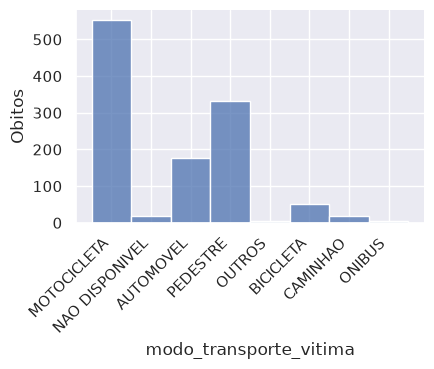

In [19]:
df_plot = df_pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(df_sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro').select('modo_transporte_vitima', 
                 'tp_sinistro_primario',
                 'obito').filter(c('obito') == 'fatal').to_pandas()

sns.displot(data=df_plot, 
            x='modo_transporte_vitima',
           height=3, aspect=1.5, 
           ) \
        .set_xticklabels(rotation=45, ha='right').set_ylabels(label='Obitos') \
        .set_titles(col_template="{col_name}", row_template="{row_name}", size=9)
plt.show()

In [21]:
df_pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(df_sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
        .group_by('modo_transporte_vitima', 
                 'obito') \
        .len() \
        .pivot(on='obito', index=['modo_transporte_vitima'], values='len') \
        .fill_null(0) \
        .with_columns((100 * (pl.col('fatal') / (pl.col('nao_fatal') + pl.col('fatal')))).round(2).alias('fatalidade')) \
        .sort('fatalidade', descending=True)

modo_transporte_vitima,fatal,nao_fatal,fatalidade
str,u32,u32,f64
"""NAO DISPONIVEL""",19,1,95.0
"""BICICLETA""",52,4,92.86
"""PEDESTRE""",331,2410,12.08
"""MOTOCICLETA""",553,16931,3.16
"""CAMINHAO""",18,1294,1.37
"""OUTROS""",5,501,0.99
"""AUTOMOVEL""",177,20177,0.87
"""ONIBUS""",5,1448,0.34


In [22]:
df_pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(df_sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
        .group_by('modo_transporte_vitima', 
                 'obito') \
        .len() \
        .pivot(on='obito', index=['modo_transporte_vitima'], values='len') \
        .with_columns((100 * c('fatal') / c('fatal').sum()).round(2).alias('percentual das fatalidades'),
                      (c('nao_fatal') + c('fatal')).alias('total'),
                      (100 * (pl.col('fatal') / (pl.col('nao_fatal') + pl.col('fatal')))).round(2).alias('fatalidade')) \
        .with_columns((100 * c('total') / c('total').sum()).round(2).alias('percentual dos acidentes'),
                      (100 * c('fatal') / c('fatal').sum()).round(2).alias('percentual das fatalidades')) \
        .with_columns(c('percentual dos acidentes').cum_sum().over(order_by='percentual dos acidentes', descending=True).alias('percentual acumulado')) \
        .sort('percentual acumulado') \
        .fill_null(0)

modo_transporte_vitima,fatal,nao_fatal,percentual das fatalidades,total,fatalidade,percentual dos acidentes,percentual acumulado
str,u32,u32,f64,u32,f64,f64,f64
"""AUTOMOVEL""",177,20177,15.26,20354,0.87,46.34,46.34
"""MOTOCICLETA""",553,16931,47.67,17484,3.16,39.8,86.14
"""PEDESTRE""",331,2410,28.53,2741,12.08,6.24,92.38
"""ONIBUS""",5,1448,0.43,1453,0.34,3.31,95.69
"""CAMINHAO""",18,1294,1.55,1312,1.37,2.99,98.68
"""OUTROS""",5,501,0.43,506,0.99,1.15,99.83
"""BICICLETA""",52,4,4.48,56,92.86,0.13,99.96
"""NAO DISPONIVEL""",19,1,1.64,20,95.0,0.05,100.01


In [ ]:
pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
        .group_by('modo_transporte_vitima', 
                 'obito') \
        .len() \
        .pivot(on='obito', index=['modo_transporte_vitima'], values='len') \
        .with_columns((100 * c('fatal') / c('fatal').sum()).round(2).alias('percentual das fatalidades'),
                      (c('nao_fatal') + c('fatal')).alias('total'),
                      (100 * (pl.col('fatal') / (pl.col('nao_fatal') + pl.col('fatal')))).round(2).alias('fatalidade')) \
        .with_columns((100 * c('fatal') / c('fatal').sum()).round(2).alias('percentual das fatalidades')) \
        .with_columns(c('percentual das fatalidades').cum_sum().over(order_by='percentual das fatalidades', descending=True).alias('percentual acumulado')) \
        .sort('percentual acumulado') \
        .fill_null(0)

In [ ]:
pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
        .group_by('modo_transporte_vitima', 
                 'obito') \
        .len() \
        .pivot(on='obito', index=['modo_transporte_vitima'], values='len') \
        .with_columns((c('nao_fatal') + c('fatal')).alias('total'),
                      (100 * (pl.col('fatal') / (pl.col('nao_fatal') + pl.col('fatal')))).round(2).alias('fatalidade')) \
        .with_columns((100 * c('total') / c('total').sum()).alias('percentual_dos_casos')) \
        .sort('percentual_dos_casos', descending=True) \
        .fill_null(0)

In [ ]:
pessoas.with_columns(pl.when(pl.col('tempo_sinistro_obito').is_not_null())
                        .then(pl.lit('fatal'))
                        .otherwise(pl.lit('nao_fatal')).alias('obito')) \
        .join(sinistros.select('id_sinistro', 'tp_sinistro_primario'), on='id_sinistro') \
        .group_by('modo_transporte_vitima', 
                 'tp_sinistro_primario',
                 'obito') \
        .len() \
        .pivot(on='obito', index=['modo_transporte_vitima', 'tp_sinistro_primario'], values='len') \
        .fill_null(0) \
        .with_columns((100 * (pl.col('fatal') / (pl.col('nao_fatal') + pl.col('fatal')))).round(2).alias('fatalidade')) \
        .sort('fatalidade', descending=True)

In [ ]:
pessoas.filter(pl.col('gravidade_lesao') == 'NAO DISPONIVEL')

In [ ]:
pessoas.filter(pl.col('id_sinistro') == 2723740)

In [ ]:
sinistros.filter(pl.col('id_sinistro') == 2723740)

In [ ]:
pessoas.filter(pl.col('tipo_de_vitima') == 'NAO DISPONIVEL') \
.group_by('id_sinistro').agg(pl.col('gravidade_lesao')).filter(pl.col('gravidade_lesao').list.len() == 1)\
.join(sinistros, on='id_sinistro')

In [ ]:
pessoas.join(sinistros.select('id_sinistro', 'tipo_registro'), on='id_sinistro')
.join().group_by('tipo_registro', 'id_sinistro') \
    .agg(pl.col('id_veiculo').drop_nulls(), pl.col('id_pessoa')) \
    .filter(pl.col('id_veiculo').list.len() == 0)

In [ ]:
sinistros.filter(pl.col('id_sinistro') == 2677915)